In [2]:
!pip install transformers datasets einops matplotlib

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import math

from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.optim import AdamW

from torch.amp import autocast, GradScaler

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [5]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

In [6]:
baseline_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
baseline_model.eval()

print("Baseline GPT2 loaded")

Baseline GPT2 loaded


In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [8]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

In [9]:
def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized = dataset.map(tokenize, batched=True, remove_columns=["text"])
tokenized.set_format("torch")

Map:   0%|          | 0/4358 [00:00<?, ? examples/s]

Map:   0%|          | 0/36718 [00:00<?, ? examples/s]

Map:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [10]:
train_loader = DataLoader(
    tokenized["train"].select(range(2000)),
    batch_size=16
)

eval_loader = DataLoader(
    tokenized["validation"].select(range(500)),
    batch_size=16
)

In [11]:
def evaluate_perplexity(model, loader):

    model.eval()

    total_loss = 0
    steps = 0

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            labels = input_ids.clone()
            labels[attention_mask == 0] = -100

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()
            steps += 1

    return math.exp(total_loss / steps)

In [12]:
baseline_ppl = evaluate_perplexity(baseline_model, eval_loader)

print("Baseline PPL:", baseline_ppl)

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Baseline PPL: 60.27171013912783


In [13]:
start = time.time()

_ = evaluate_perplexity(baseline_model, eval_loader)

baseline_time = time.time() - start

print("Baseline evaluation time:", baseline_time)

Baseline evaluation time: 3.8237521648406982


In [14]:
def kron_rank1(W, m1, m2, n1, n2):

    W = W.reshape(m1, m2, n1, n2)
    W = W.permute(0,2,1,3).reshape(m1*n1, m2*n2)

    U,S,Vh = torch.linalg.svd(W, full_matrices=False)

    u = U[:,0]
    v = Vh[0,:]
    s = S[0]

    A = (u*math.sqrt(s)).reshape(m1,n1)
    B = (v*math.sqrt(s)).reshape(m2,n2)

    return A.to(device), B.to(device)

In [15]:
class KronLinear(nn.Module):

    def __init__(self, A, B, bias):

        super().__init__()

        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)

        self.bias = nn.Parameter(bias)


    def forward(self, x):

        W = torch.kron(self.A, self.B)

        return torch.matmul(x, W.t()) + self.bias

In [16]:
axb_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

for i in range(12):

    block = axb_model.transformer.h[i]

    W = block.mlp.c_fc.weight.data
    b = block.mlp.c_fc.bias.data

    A,B = kron_rank1(W,48,64,12,64)

    block.mlp.c_fc = KronLinear(A,B,b)

axb_model.eval()

print("AxB model ready")

AxB model ready


In [17]:
def kron_abc(W, m1,m2,m3, n1,n2,n3):

    W = W.reshape(m1,m2,m3,n1,n2,n3)

    W = W.permute(0,3,1,4,2,5).reshape(m1*n1, m2*n2*m3*n3)

    U,S,Vh = torch.linalg.svd(W, full_matrices=False)

    A = (U[:,0]*math.sqrt(S[0])).reshape(m1,n1)

    B = torch.randn(m2,n2).to(device)
    C = torch.randn(m3,n3).to(device)

    return A,B,C

In [19]:
class KronABCLinear(nn.Module):

    def __init__(self, A,B,C,bias):

        super().__init__()

        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)
        self.C = nn.Parameter(C)

        self.bias = nn.Parameter(bias)

    def forward(self,x):

        W = torch.kron(torch.kron(self.A,self.B),self.C)

        return torch.matmul(x,W.t()) + self.bias
        

In [20]:
abc_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

for i in range(12):

    block = abc_model.transformer.h[i]

    W = block.mlp.c_fc.weight.data
    b = block.mlp.c_fc.bias.data

    A,B,C = kron_abc(W,3,16,64,3,16,16)

    block.mlp.c_fc = KronABCLinear(A,B,C,b)

abc_model.eval()

print("AxBxC model ready")

AxBxC model ready


In [21]:
baseline_params = count_parameters(baseline_model)
axb_params = count_parameters(axb_model)
abc_params = count_parameters(abc_model)

print("Baseline:", baseline_params)
print("AxB:", axb_params)
print("AxBxC:", abc_params)

Baseline: 124439808
AxB: 96184320
AxBxC: 96143724


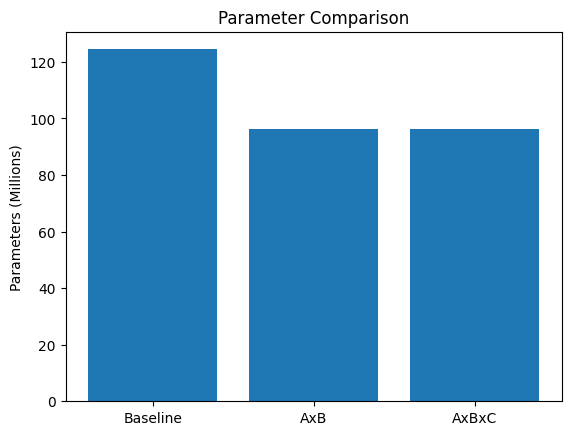

In [22]:
plt.figure()

plt.bar(
    ["Baseline","AxB","AxBxC"],
    [baseline_params/1e6, axb_params/1e6, abc_params/1e6]
)

plt.ylabel("Parameters (Millions)")
plt.title("Parameter Comparison")

plt.show()